In [1]:
!pip install transformers torch bertviz matplotlib -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json, torch, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoModelForCausalLM, AutoTokenizer

CONDITIONS   = ["reply_only", "useful", "irrelevant", "conflicting", "mixed", "lexical"]
LABEL_MAP    = {"support": 0, "deny": 1, "query": 2, "comment": 3}
VALID_LABELS = {"support", "deny", "query", "comment"}

/opt/jupyter/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:


# 데이터 로드
with open('../context_conditions.json', encoding='utf-8') as f:
    full_dataset = json.load(f)
dataset      = [d for d in full_dataset if d['split'] == 'dev']
query_samples = [d for d in dataset if d['label'] == 'query' and d['conflicting'] is not None]
print(f"dev: {len(dataset)}개 / query: {len(query_samples)}개")

# 모델 로드 (output_attentions 없이)
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print("모델 로드 완료!")

VALID_LABELS = {"support", "deny", "query", "comment"}
SYSTEM_PROMPT = """You are a stance classification expert for social media discussions about rumours.

Classify the stance of the TARGET reply using exactly one of these four labels:

- support: The reply explicitly states the rumour IS true or confirmed.
- deny: The reply explicitly states the rumour IS false or fabricated.
- query: The reply asks for sources, evidence, or verification.
- comment: Everything else. The reply does not directly address whether the rumour is true or false.

Respond with ONLY one word: support, deny, query, or comment. No explanation."""

def build_prompt(text):
    cleaned = text
    cleaned = cleaned.replace("[Source]",     "Rumour post:")
    cleaned = cleaned.replace("[Context]",    "Previous reply:")
    cleaned = cleaned.replace("[Misleading]", "Another reply:")
    cleaned = cleaned.replace("[Target]",     "Reply to classify:")
    user_content = (
        f"Read the following and classify the stance of the 'Reply to classify'.\n\n"
        f"{cleaned}\n\n"
        f"Stance label (support / deny / query / comment):"
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]

def predict(text):
    messages   = build_prompt(text)
    text_input = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text_input, return_tensors="pt",
                      return_attention_mask=True).to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][inputs['input_ids'].shape[-1]:]
    raw        = tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()
    return next((l for l in VALID_LABELS if l in raw), "invalid")

# 테스트
sample = query_samples[5]
print(f"\n정답: {sample['label']}")
print(f"useful 예측: {predict(sample['useful'])}")
print(f"conflicting 예측: {predict(sample['conflicting'])}")

dev: 1447개 / query: 99개


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 509.51it/s]


모델 로드 완료!

정답: query
useful 예측: query
conflicting 예측: query


In [12]:
# useful 맞고 conflicting 틀린 샘플 찾기
print("샘플 탐색 중...")
target_sample = None

for d in query_samples:
    p_useful = predict(d['useful'])
    p_conf   = predict(d['conflicting'])
    if p_useful == d['label'] and p_conf != d['label']:
        target_sample = d
        target_useful_pred = p_useful
        target_conf_pred   = p_conf
        print(f"찾았어!")
        print(f"  정답: {d['label']}")
        print(f"  useful 예측: {p_useful}")
        print(f"  conflicting 예측: {p_conf}")
        print(f"\n[useful]")
        print(d['useful'])
        print(f"\n[conflicting]")
        print(d['conflicting'])
        break

if target_sample is None:
    print("query에서 못 찾았어. deny 레이블로 시도해볼게.")
    deny_samples = [d for d in dataset if d['label'] == 'deny' and d['conflicting'] is not None]
    for d in deny_samples:
        p_useful = predict(d['useful'])
        p_conf   = predict(d['conflicting'])
        if p_useful == d['label'] and p_conf != d['label']:
            target_sample = d
            target_useful_pred = p_useful
            target_conf_pred   = p_conf
            print(f"찾았어!")
            print(f"  정답: {d['label']}")
            print(f"  useful 예측: {p_useful}")
            print(f"  conflicting 예측: {p_conf}")
            break

샘플 탐색 중...
찾았어!
  정답: query
  useful 예측: query
  conflicting 예측: deny

[useful]
[Source] Secret Service tells Infowars: Hillary seriously ill; needs special accommodations Tune in 4pm-6pm CST https://t.co/OQtch0Lewb #trump #tcot
[Context] @RealAlexJones @infowars why would the secret service even talk to Infowars?
[Target] @thingfish69 @RealAlexJones @infowars And doesn't the "secret service" operate in secret?

[conflicting]
[Source] Secret Service tells Infowars: Hillary seriously ill; needs special accommodations Tune in 4pm-6pm CST https://t.co/OQtch0Lewb #trump #tcot
[Context] @RealAlexJones @infowars this just in your a fake and we all know it ... Shame on you
[Target] @thingfish69 @RealAlexJones @infowars And doesn't the "secret service" operate in secret?


In [13]:
def get_attention(text):
    messages   = build_prompt(text)
    text_input = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text_input, return_tensors="pt",
                      return_attention_mask=True).to(model.device)

    with torch.no_grad():
        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            output_attentions=True
        )

    # 마지막 레이어, 모든 헤드 평균, 마지막 토큰 기준
    last_attn   = outputs.attentions[-1][0].float()  # (heads, seq, seq)
    avg_attn    = last_attn.mean(dim=0)              # (seq, seq)
    last_token  = avg_attn[-1]                       # (seq,)
    last_token  = torch.softmax(last_token, dim=0)

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    return tokens, last_token.cpu().numpy()


def plot_attention(tokens_a, attn_a, pred_a,
                   tokens_b, attn_b, pred_b,
                   gold, max_tokens=40):

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for ax, tokens, attn, pred, title in zip(
        axes,
        [tokens_a, tokens_b],
        [attn_a,   attn_b],
        [pred_a,   pred_b],
        ["Useful Context", "Conflicting Context"]
    ):
        # 마지막 max_tokens개만
        tokens = tokens[-max_tokens:]
        attn   = attn[-max_tokens:]

        # 토큰 정리
        clean = []
        for t in tokens:
            t = t.replace('Ġ', ' ').replace('▁', ' ').replace('<0x0A>', '\\n')
            t = t[:12] + '..' if len(t) > 12 else t
            clean.append(t)

        threshold = np.percentile(attn, 75)
        colors    = ['#E74C3C' if a >= threshold else '#3498DB' for a in attn]

        ax.barh(range(len(clean)), attn, color=colors, alpha=0.85, edgecolor='white')
        ax.set_yticks(range(len(clean)))
        ax.set_yticklabels(clean, fontsize=9, fontfamily='monospace')
        ax.set_xlabel('Attention Weight', fontsize=11)
        ax.invert_yaxis()

        ok    = pred == gold
        color = 'green' if ok else 'red'
        mark  = '✓' if ok else '✗'
        ax.set_title(
            f"{title}\nPred: {pred} {mark}   Gold: {gold}",
            fontsize=12, color=color, fontweight='bold'
        )
        ax.axvline(x=threshold, color='gray', linestyle='--', alpha=0.5, label='Top 25% threshold')

    plt.suptitle(
        "Attention Analysis: What does the model focus on?\n"
        "(Red = top 25% attention, Blue = lower attention)",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('attention_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("저장 완료: attention_analysis.png")


# 실행
tokens_u, attn_u = get_attention(target_sample['useful'])
tokens_c, attn_c = get_attention(target_sample['conflicting'])

plot_attention(
    tokens_u, attn_u, target_useful_pred,
    tokens_c, attn_c, target_conf_pred,
    gold=target_sample['label']
)

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


IndexError: tuple index out of range

In [14]:
import gc
del model
torch.cuda.empty_cache()
gc.collect()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    attn_implementation="eager"  # ★ 이거 추가
)
model.eval()
print("모델 재로드 완료!")

# 테스트
tokens_u, attn_u = get_attention(target_sample['useful'])
tokens_c, attn_c = get_attention(target_sample['conflicting'])
print(f"토큰 수: useful={len(tokens_u)}, conflicting={len(tokens_c)}")

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 520.06it/s]


모델 재로드 완료!
토큰 수: useful=249, conflicting=253


In [16]:
# attention 값 직접 확인
messages   = build_prompt(target_sample['useful'])
text_input = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
inputs = tokenizer(text_input, return_tensors="pt",
                  return_attention_mask=True).to(model.device)

with torch.no_grad():
    outputs = model(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        output_attentions=True
    )

print(f"attention 레이어 수: {len(outputs.attentions)}")
if outputs.attentions:
    a = outputs.attentions[-1]
    print(f"shape: {a.shape}")
    print(f"min: {a.min().item():.6f}")
    print(f"max: {a.max().item():.6f}")
    print(f"mean: {a.mean().item():.6f}")
else:
    print("attention이 비어있어!")

attention 레이어 수: 28
shape: torch.Size([1, 12, 249, 249])
min: nan
max: nan
mean: nan


In [17]:
import gc
del model
torch.cuda.empty_cache()
gc.collect()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,  # ★ float16 → bfloat16
    device_map="auto",
    attn_implementation="eager"
)
model.eval()
print("모델 재로드 완료!")

# attention 값 재확인
messages   = build_prompt(target_sample['useful'])
text_input = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
inputs = tokenizer(text_input, return_tensors="pt",
                  return_attention_mask=True).to(model.device)

with torch.no_grad():
    outputs = model(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        output_attentions=True
    )

a = outputs.attentions[-1]
print(f"shape: {a.shape}")
print(f"min: {a.min().item():.6f}")
print(f"max: {a.max().item():.6f}")
print(f"mean: {a.mean().item():.6f}")

Loading weights: 100%|██████████| 338/338 [00:00<00:00, 1132.41it/s]


모델 재로드 완료!
shape: torch.Size([1, 12, 249, 249])
min: 0.000000
max: 1.000000
mean: 0.004028


useful   - max attn: 0.0996, mean: 0.0040
conflict - max attn: 0.0910, mean: 0.0040


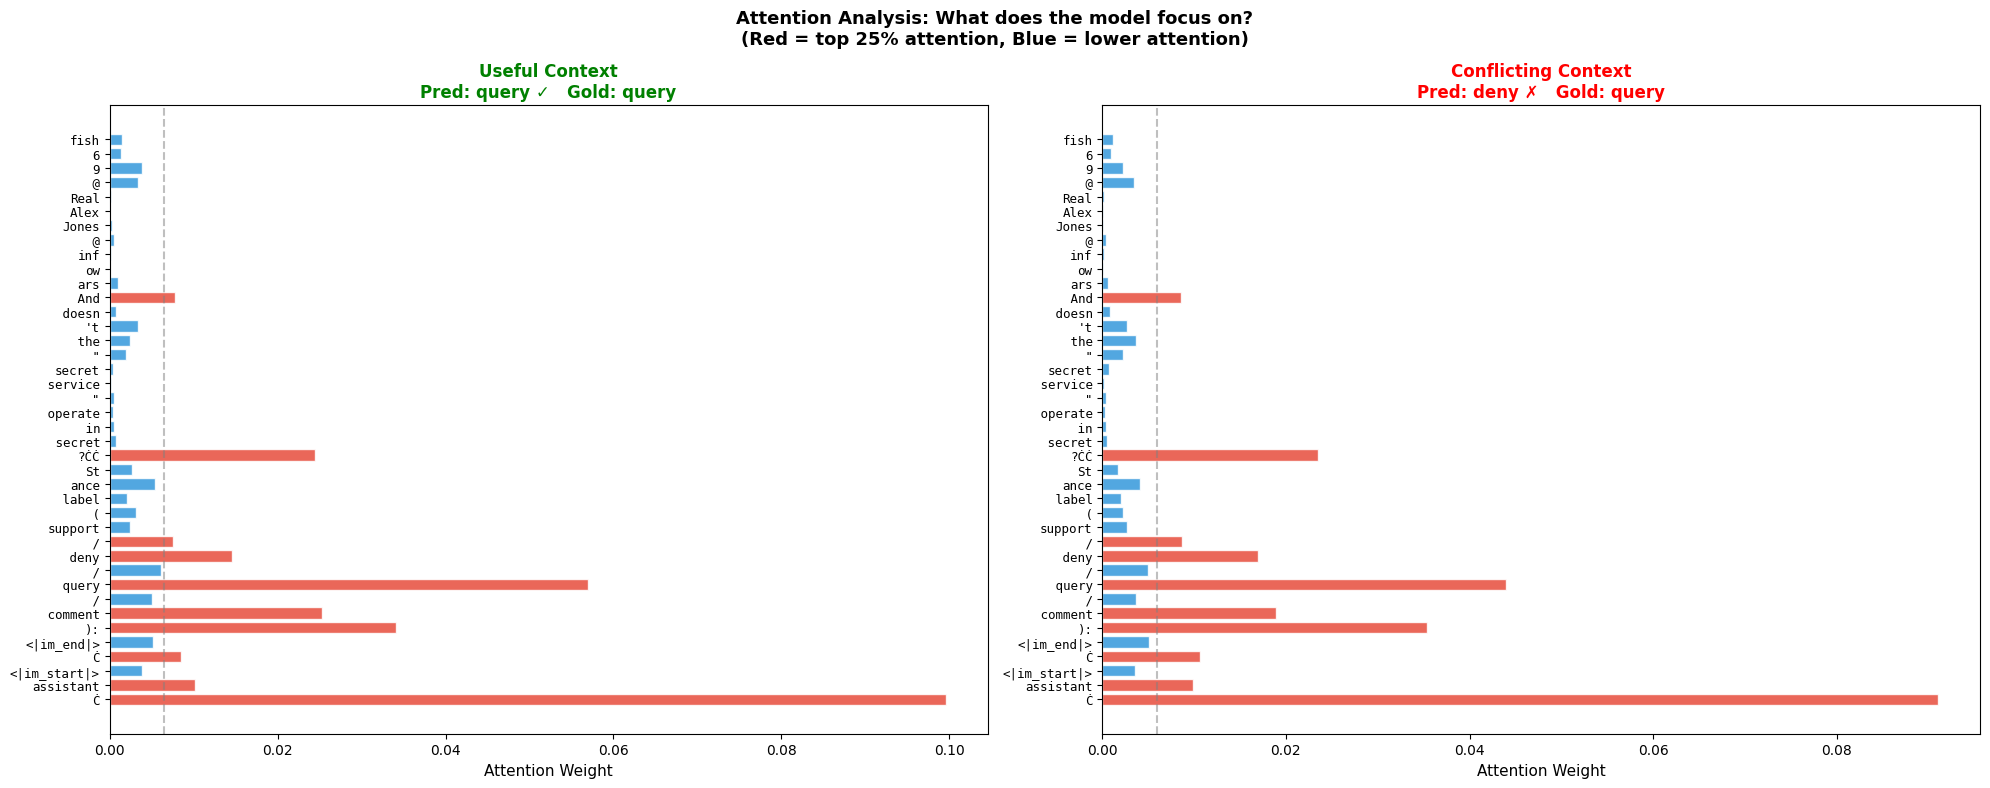

저장 완료: attention_analysis.png


In [18]:
# attention 추출 함수 업데이트 (bfloat16 버전)
def get_attention(text):
    messages   = build_prompt(text)
    text_input = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text_input, return_tensors="pt",
                      return_attention_mask=True).to(model.device)

    with torch.no_grad():
        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            output_attentions=True
        )

    # 마지막 레이어, 모든 헤드 평균, 마지막 토큰 기준
    last_attn  = outputs.attentions[-1][0].float()  # (heads, seq, seq)
    avg_attn   = last_attn.mean(dim=0)              # (seq, seq)
    last_token = avg_attn[-1]                       # (seq,)

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    return tokens, last_token.cpu().numpy()

# 실행
tokens_u, attn_u = get_attention(target_sample['useful'])
tokens_c, attn_c = get_attention(target_sample['conflicting'])

print(f"useful   - max attn: {attn_u.max():.4f}, mean: {attn_u.mean():.4f}")
print(f"conflict - max attn: {attn_c.max():.4f}, mean: {attn_c.mean():.4f}")

# 시각화
plot_attention(
    tokens_u, attn_u, target_useful_pred,
    tokens_c, attn_c, target_conf_pred,
    gold=target_sample['label']
)

In [19]:
# 여러 샘플 분석
all_labels = ['query', 'deny', 'support', 'comment']
flip_samples = []

print("useful 맞고 conflicting 틀린 샘플 찾는 중...")

for label in all_labels:
    label_samples = [d for d in dataset if d['label'] == label and d['conflicting'] is not None]
    count = 0
    for d in label_samples:
        if count >= 3:  # 레이블당 최대 3개
            break
        p_useful = predict(d['useful'])
        p_conf   = predict(d['conflicting'])
        if p_useful == d['label'] and p_conf != d['label']:
            tokens_u, attn_u = get_attention(d['useful'])
            tokens_c, attn_c = get_attention(d['conflicting'])
            flip_samples.append({
                'label':     d['label'],
                'tokens_u':  tokens_u,
                'attn_u':    attn_u,
                'pred_u':    p_useful,
                'tokens_c':  tokens_c,
                'attn_c':    attn_c,
                'pred_c':    p_conf,
            })
            count += 1
            print(f"  [{label}] useful={p_useful} → conflicting={p_conf}")

print(f"\n총 {len(flip_samples)}개 샘플 찾음")

useful 맞고 conflicting 틀린 샘플 찾는 중...
  [query] useful=query → conflicting=deny
  [query] useful=query → conflicting=deny
  [query] useful=query → conflicting=deny
  [deny] useful=deny → conflicting=query
  [deny] useful=deny → conflicting=query
  [comment] useful=comment → conflicting=query
  [comment] useful=comment → conflicting=query
  [comment] useful=comment → conflicting=query

총 8개 샘플 찾음


Gold     Pred_U   Pred_C     |       Useful→        |      Conflict→      
                           |    top attn token    |    top attn token   
query    query    deny       |        query         |        query        
query    query    deny       |        query         |        query        
query    query    deny       |        query         |        query        
deny     deny     query      |        query         |        query        
deny     deny     query      |        query         |        query        
comment  comment  query      |        query         |        query        
comment  comment  query      |        query         |        query        
comment  comment  query      |        query         |        query        

=== 패턴 요약 ===
Useful context에서 가장 많이 집중한 레이블: [('query', 8)]
Conflicting context에서 가장 많이 집중한 레이블: [('query', 8)]


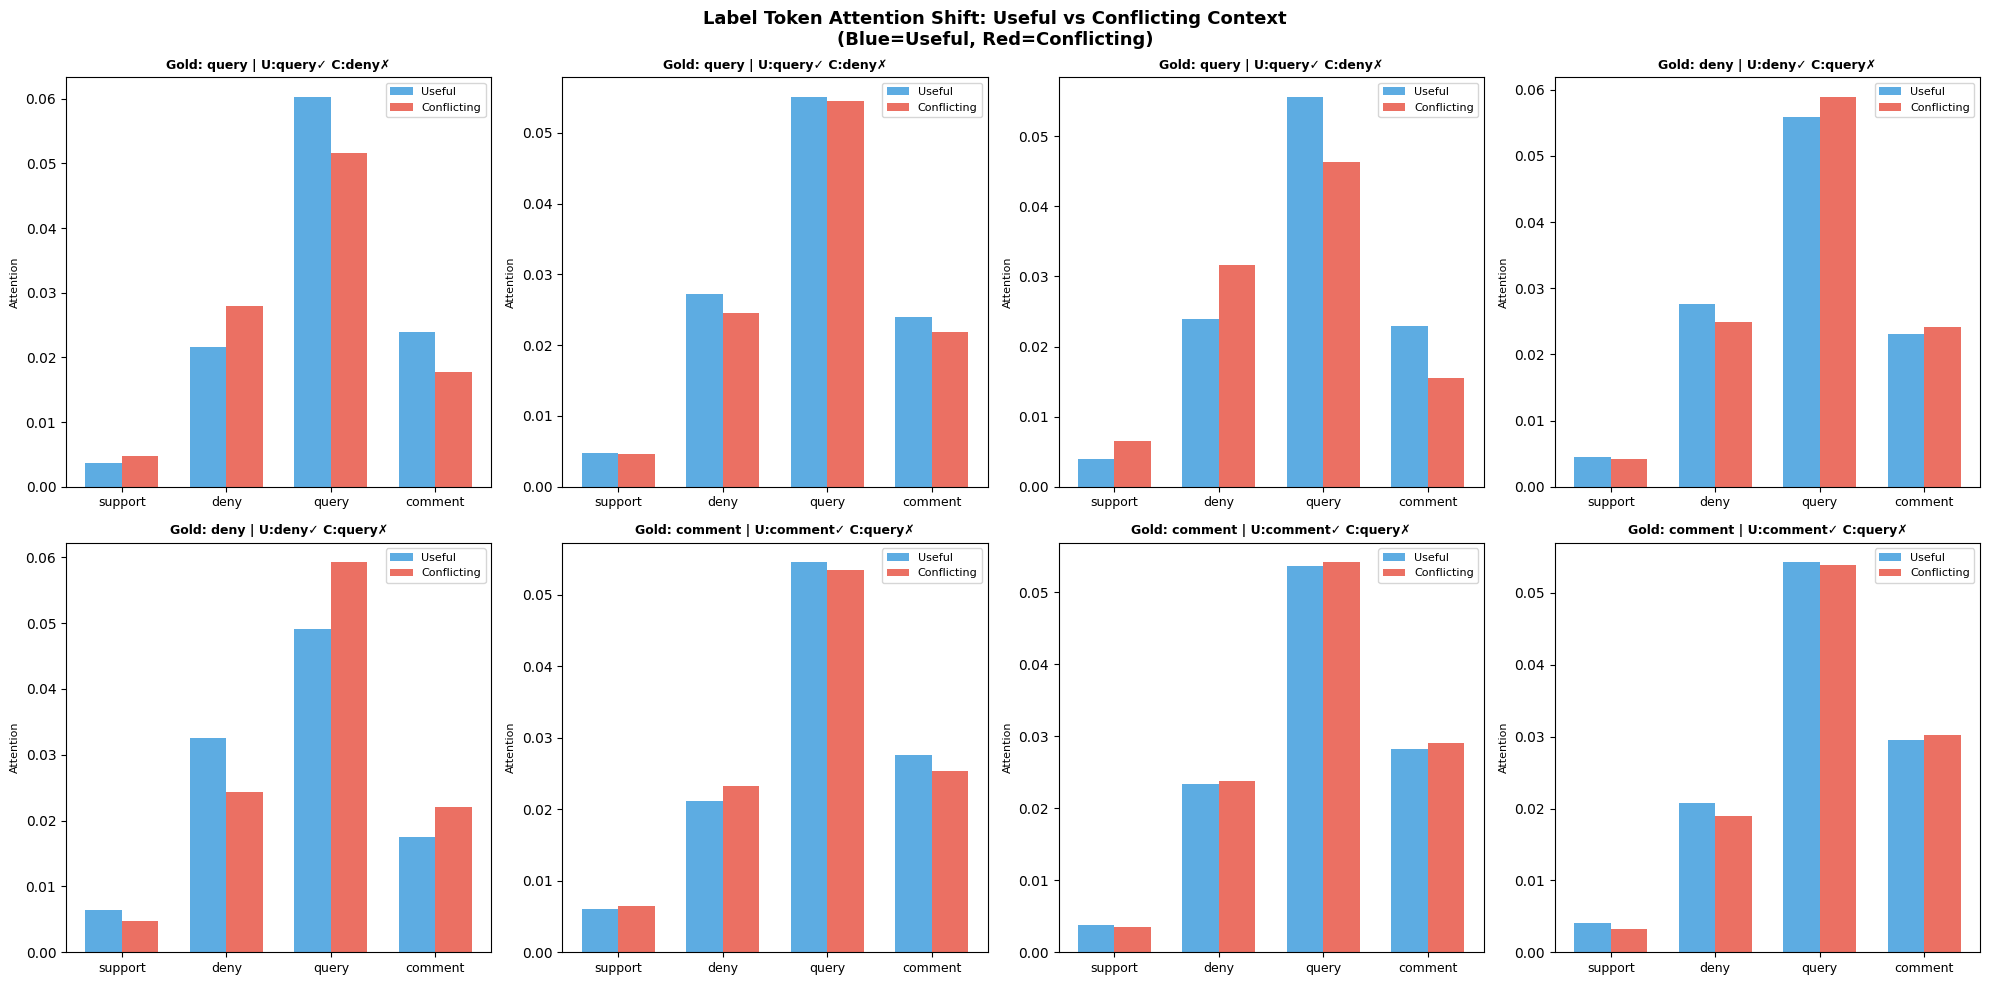

저장 완료: attention_shift_analysis.png


In [20]:
# 레이블 토큰별 attention 평균 비교
LABEL_TOKENS = ['support', 'deny', 'query', 'comment']

def get_label_token_attention(tokens, attn):
    """레이블 토큰들에 대한 attention 값 추출"""
    result = {}
    for label in LABEL_TOKENS:
        indices = [i for i, t in enumerate(tokens) 
                   if label in t.lower().replace('▁', '').replace('Ġ', '')]
        if indices:
            result[label] = float(np.mean([attn[i] for i in indices]))
        else:
            result[label] = 0.0
    return result

# 전체 샘플 분석
print("="*65)
print(f"{'Gold':<8} {'Pred_U':<8} {'Pred_C':<10} | {'Useful→':^20} | {'Conflict→':^20}")
print(f"{'':26} | {'top attn token':^20} | {'top attn token':^20}")
print("="*65)

useful_shifts    = []
conflict_shifts  = []

for s in flip_samples:
    attn_u = get_label_token_attention(s['tokens_u'], s['attn_u'])
    attn_c = get_label_token_attention(s['tokens_c'], s['attn_c'])

    top_u = max(attn_u, key=attn_u.get)
    top_c = max(attn_c, key=attn_c.get)

    useful_shifts.append(top_u)
    conflict_shifts.append(top_c)

    print(f"{s['label']:<8} {s['pred_u']:<8} {s['pred_c']:<10} | {top_u:^20} | {top_c:^20}")

print("="*65)
print(f"\n=== 패턴 요약 ===")
from collections import Counter
print(f"Useful context에서 가장 많이 집중한 레이블: {Counter(useful_shifts).most_common()}")
print(f"Conflicting context에서 가장 많이 집중한 레이블: {Counter(conflict_shifts).most_common()}")

# 시각화: attention shift 비교
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, s in enumerate(flip_samples):
    ax = axes[idx]
    attn_u = get_label_token_attention(s['tokens_u'], s['attn_u'])
    attn_c = get_label_token_attention(s['tokens_c'], s['attn_c'])

    x     = np.arange(len(LABEL_TOKENS))
    width = 0.35

    bars_u = ax.bar(x - width/2, [attn_u[l] for l in LABEL_TOKENS],
                    width, label='Useful', color='#3498DB', alpha=0.8)
    bars_c = ax.bar(x + width/2, [attn_c[l] for l in LABEL_TOKENS],
                    width, label='Conflicting', color='#E74C3C', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(LABEL_TOKENS, fontsize=9)
    ax.set_title(
        f"Gold: {s['label']} | U:{s['pred_u']}✓ C:{s['pred_c']}✗",
        fontsize=9, fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.set_ylabel('Attention', fontsize=8)

# 빈 subplot 숨기기
for idx in range(len(flip_samples), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Label Token Attention Shift: Useful vs Conflicting Context\n"
    "(Blue=Useful, Red=Conflicting)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('attention_shift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: attention_shift_analysis.png")

In [21]:
def get_region_attention(tokens, attn, text):
    """텍스트 영역별 attention 합계"""
    # 각 영역의 키워드로 구분
    regions = {
        'source':     [],
        'context':    [],
        'target':     [],
        'prompt':     [],
    }

    current_region = 'prompt'
    for i, token in enumerate(tokens):
        t = token.replace('▁', ' ').replace('Ġ', ' ').strip().lower()
        if 'rumour' in t and 'post' in t:
            current_region = 'source'
        elif 'previous' in t or 'another' in t:
            current_region = 'context'
        elif 'reply' in t and 'classify' in t:
            current_region = 'target'
        elif 'stance' in t and 'label' in t:
            current_region = 'prompt'
        regions[current_region].append(attn[i])

    return {k: float(np.sum(v)) for k, v in regions.items() if v}


print("="*70)
print(f"{'Gold':<8} {'Pred_U':<8} {'Pred_C':<8} | {'Useful attention':^25} | {'Conflicting':^25}")
print("="*70)

for s in flip_samples:
    reg_u = get_region_attention(s['tokens_u'], s['attn_u'], '')
    reg_c = get_region_attention(s['tokens_c'], s['attn_c'], '')

    u_str = f"S:{reg_u.get('source',0):.3f} C:{reg_u.get('context',0):.3f} T:{reg_u.get('target',0):.3f}"
    c_str = f"S:{reg_c.get('source',0):.3f} C:{reg_c.get('context',0):.3f} T:{reg_c.get('target',0):.3f}"

    print(f"{s['label']:<8} {s['pred_u']:<8} {s['pred_c']:<8} | {u_str:^25} | {c_str:^25}")

print("="*70)
print("S=Source, C=Context, T=Target")

# 평균 비교
import pandas as pd

useful_regions    = {'source': [], 'context': [], 'target': []}
conflict_regions  = {'source': [], 'context': [], 'target': []}

for s in flip_samples:
    reg_u = get_region_attention(s['tokens_u'], s['attn_u'], '')
    reg_c = get_region_attention(s['tokens_c'], s['attn_c'], '')
    for k in ['source', 'context', 'target']:
        useful_regions[k].append(reg_u.get(k, 0))
        conflict_regions[k].append(reg_c.get(k, 0))

print("\n=== 평균 attention (전체 샘플) ===")
print(f"{'영역':<10} {'Useful':>10} {'Conflicting':>12} {'차이':>8}")
print("-"*42)
for k in ['source', 'context', 'target']:
    u_mean = np.mean(useful_regions[k])
    c_mean = np.mean(conflict_regions[k])
    print(f"{k:<10} {u_mean:>10.4f} {c_mean:>12.4f} {c_mean-u_mean:>+8.4f}")

Gold     Pred_U   Pred_C   |     Useful attention      |        Conflicting       
query    query    deny     |  S:0.000 C:0.436 T:0.000  |  S:0.000 C:0.409 T:0.000 
query    query    deny     |  S:0.000 C:0.000 T:0.000  |  S:0.000 C:0.402 T:0.000 
query    query    deny     |  S:0.000 C:0.000 T:0.000  |  S:0.000 C:0.407 T:0.000 
deny     deny     query    |  S:0.000 C:0.000 T:0.000  |  S:0.000 C:0.425 T:0.000 
deny     deny     query    |  S:0.000 C:0.414 T:0.000  |  S:0.000 C:0.441 T:0.000 
comment  comment  query    |  S:0.000 C:0.416 T:0.000  |  S:0.000 C:0.422 T:0.000 
comment  comment  query    |  S:0.000 C:0.411 T:0.000  |  S:0.000 C:0.427 T:0.000 
comment  comment  query    |  S:0.000 C:0.468 T:0.000  |  S:0.000 C:0.433 T:0.000 
S=Source, C=Context, T=Target

=== 평균 attention (전체 샘플) ===
영역             Useful  Conflicting       차이
------------------------------------------
source         0.0000       0.0000  +0.0000
context        0.2681       0.4207  +0.1526
target         0.0

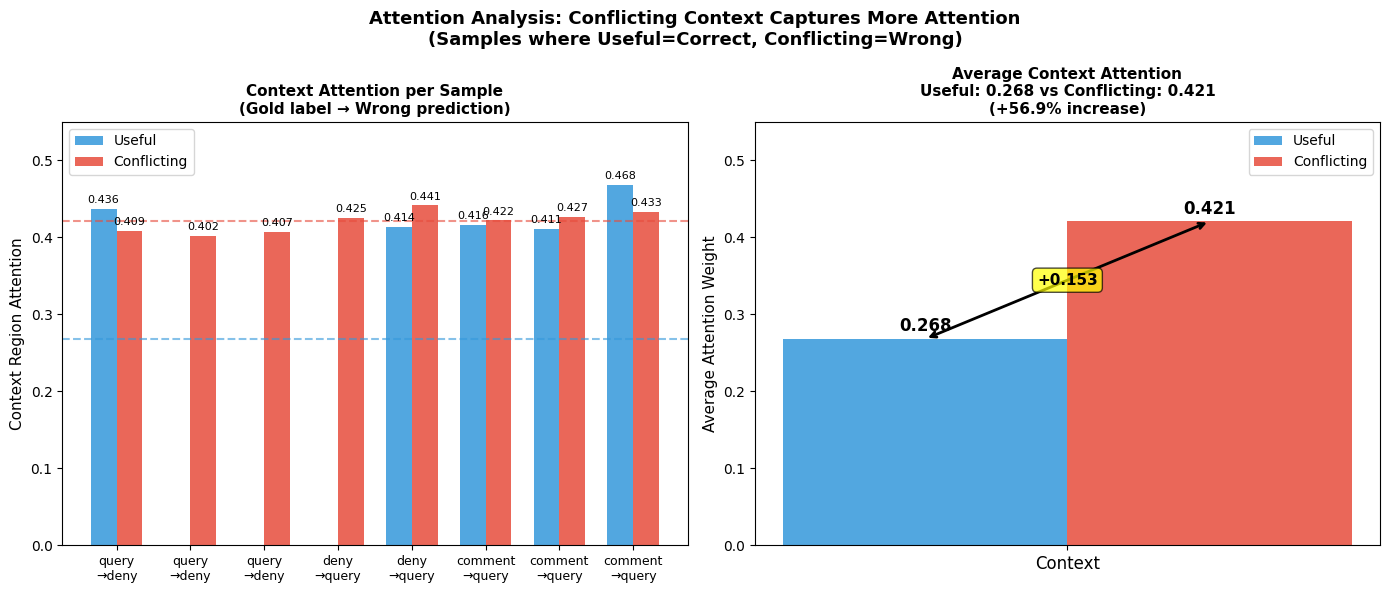

저장 완료: attention_region_analysis.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 정리
useful_context    = [s for s in [get_region_attention(s['tokens_u'], s['attn_u'], '')
                                  .get('context', 0) for s in flip_samples]]
conflict_context  = [s for s in [get_region_attention(s['tokens_c'], s['attn_c'], '')
                                  .get('context', 0) for s in flip_samples]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 샘플별 context attention 비교
ax = axes[0]
x  = np.arange(len(flip_samples))
w  = 0.35

labels = [f"{s['label']}\n→{s['pred_c']}" for s in flip_samples]
bars_u = ax.bar(x - w/2, useful_context,   w, label='Useful',      color='#3498DB', alpha=0.85)
bars_c = ax.bar(x + w/2, conflict_context, w, label='Conflicting', color='#E74C3C', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Context Region Attention', fontsize=11)
ax.set_title('Context Attention per Sample\n(Gold label → Wrong prediction)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.55)
ax.axhline(y=np.mean(useful_context),   color='#3498DB', linestyle='--', alpha=0.6, label='Useful mean')
ax.axhline(y=np.mean(conflict_context), color='#E74C3C', linestyle='--', alpha=0.6, label='Conflict mean')

# 값 표시
for bar in bars_u:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

# 오른쪽: 평균 비교
ax2 = axes[1]
regions    = ['Context']
u_means    = [np.mean(useful_context)]
c_means    = [np.mean(conflict_context)]

x2  = np.arange(len(regions))
b_u = ax2.bar(x2 - w/2, u_means, w, label='Useful',      color='#3498DB', alpha=0.85)
b_c = ax2.bar(x2 + w/2, c_means, w, label='Conflicting', color='#E74C3C', alpha=0.85)

ax2.set_xticks(x2)
ax2.set_xticklabels(regions, fontsize=12)
ax2.set_ylabel('Average Attention Weight', fontsize=11)
ax2.set_title(
    f'Average Context Attention\nUseful: {u_means[0]:.3f} vs Conflicting: {c_means[0]:.3f}\n'
    f'(+{(c_means[0]-u_means[0])/u_means[0]*100:.1f}% increase)',
    fontsize=11, fontweight='bold'
)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 0.55)

for bar in [b_u[0], b_c[0]]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 유의미한 차이 표시
ax2.annotate('', xy=(0 + w/2, c_means[0]), xytext=(0 - w/2, u_means[0]),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(0, (u_means[0] + c_means[0])/2, f'+{c_means[0]-u_means[0]:.3f}',
         ha='center', va='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle(
    'Attention Analysis: Conflicting Context Captures More Attention\n'
    '(Samples where Useful=Correct, Conflicting=Wrong)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('attention_region_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: attention_region_analysis.png")